## IMS Bearing Dataset — Data Understanding & EDA
### Dataset Info - 2nd dataset 
- Recording: Feb 12, 2004 10:32:39 → Feb 19, 2004 06:22:39
- Files: 984 | Channels: 4 | Interval: every ~10 min
- Sampling Rate: 20 kHz | Points per file: 20,480
- Failure: Outer race failure in Bearing 1
- Channel Arrangement: B1=Ch1, B2=Ch2, B3=Ch3, B4=Ch4


### 1. Imports & Environment Setup

In [1]:
import os 
import glob # find files matching a pattern (e.g. *.csv)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path # cross-platform path handling 
from datetime import datetime # handle snapshot timestamps
from concurrent.futures import ThreadPoolExecutor, as_completed # parallel file reading

# Signal Processing
from scipy import signal as sp_signal
from scipy.stats import spearmanr, skew, kurtosis
from scipy.signal import hilbert, butter

# Machine Learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap

# Autocorrelation
from statsmodels.graphics.tsaplots import plot_acf

# Ignore warning to keep output clean
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print('All libraries imported.')


All libraries imported.


### 2. Theoretical Fault Frequency Analysis (Rexnord ZA-2115)

**Bearing specifications:**
- Number of rolling elements ($N_b$): 16
- Pitch diameter ($P_d$): 2.815 inches
- Roller diameter ($B_d$): 0.331 inches
- Contact angle ($\theta$): $15.17^\circ$
- FTF: Fundamental Train Frequency
- BPFO: Ball Pass Frequency Outer
- BPFI: Ball Pass Frequency Inner
- BSF: Ball Spin Frequency

Shaft speed: 2000 RPM → $f_r = 33.333$ Hz

$$FTF  = \frac{f_r}{2}\left(1 - \frac{B_d}{P_d}\cos\theta\right) \approx 14.78\text{ Hz}$$
$$BPFO = \frac{N_b}{2} f_r \left(1 - \frac{B_d}{P_d}\cos\theta\right) \approx 236.4\text{ Hz}$$
$$BPFI = \frac{N_b}{2} f_r \left(1 + \frac{B_d}{P_d}\cos\theta\right) \approx 296.9\text{ Hz}$$
$$BSF  = \frac{P_d}{2B_d} f_r \left(1 - \left(\frac{B_d}{P_d}\cos\theta\right)^2\right) \approx 139.9\text{ Hz}$$


### 3. Constants & Paths

In [2]:
# Load dataset
data_dir   = r'C:\Users\Windown\OneDrive\1_Dissertation\1_Project_Dissertation\2nd_test'
output_dir = './eda_output'
plot_dir   = os.path.join(output_dir, 'plots')
os.makedirs(plot_dir, exist_ok=True)

# Signal constants
FS       = 20_000 # Sampling frequency in Hz (samples/sec)
N_POINTS = 20_480 # Samples per snapshot/file

# Bearing labels & colors
BEARINGS = ['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4']
COLORS   = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']

# Fault frequencies (Hz) — Rexnord ZA-2115 at 2000 RPM
BPFO, BPFI, BSF, FTF = 236.4, 296.9, 139.9, 14.78
FAULT_FREQ_LABELS = {
    'BPFO': BPFO, 'BPFI': BPFI, 'BSF': BSF, 'FTF': FTF
}
FAULT_COLORS = ['#e63946', '#f4a261', '#8338ec', '#06d6a0']

# Healthy baseline length used for scaler/PCA fitting (no data leakage)
HEALTHY_N = 200

# Verify path
if os.path.isdir(data_dir):
    n_files = len(glob.glob(os.path.join(data_dir, "*.*.*.*.*.*")))
    print(f"Data directory found: {n_files} files")
else:
    print(f"Directory not found — update data_dir above")


Data directory found: 984 files


### 4. Signal Processing & Feature Extraction Functions
- Signal filtering (band selection & bandpass) => Computes spectral kurtosis across frequency bins → selects the sub-band with peak kurtosis as the optimal resonance band → applies the Butterworth bandpass filter over that band
- Time-domain to frequency-domain transformation => Computes the windowed FFT spectrum of a signal directly, or — after bandpass filtering and Hilbert-transform demodulation — of its envelope, to expose amplitude-modulated fault frequencies hidden within structural resonances.
- Feature extraction => Computes time-domain features (8 features) and Frequency-domain features (6 features) and Combines the time-domain and frequency-domain features across all 4 bearing channels into a single flat feature vector per snapshot, with each feature labelled by channel index (e.g. rms_0, bpfo_amp_2) to avoid naming collisions — yielding 56 features (14 × 4 channels) per file


In [3]:
# Signal filtering (band selection & bandpass)
# Spectral Kurtosis (SK) via STFT: per frequency bin, kurtosis of magnitude
# across time — high SK = impulsive fault energy at that frequency.
def compute_spectral_kurtosis(signal, fs=FS, nperseg=256, noverlap=None):
    if noverlap is None:
        noverlap = nperseg // 2 # default to 50% overlap (standard for STFT with Hann window)
    f, t, Zxx = sp_signal.stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
    # f: frequency bins (Hz)
    # t: time frames (s)
    # Zxx: complex STFT matrix (freq × time)
    mag = np.abs(Zxx) # magnitude at each (freq, time) bin
    sk = kurtosis(mag, axis=1, fisher=True) # kurtosis over time, per frequency bin
    return f, sk

# Finds the resonance band most excited by fault impulses via spectral kurtosis:
def find_optimal_band(signal, fs=FS, nperseg=256, bandwidth=None,
                       min_bandwidth=300, max_bandwidth=3000,
                       search_range=(300, None)):
    low_search, high_search = search_range # unpack search boundaries
    if high_search is None:
        high_search = fs / 2 - 1 # default to just under Nyquist

    f, sk = compute_spectral_kurtosis(signal, fs=fs, nperseg=nperseg)

    mask = (f >= low_search) & (f <= high_search) # keep only valid search range
    f_valid, sk_valid = f[mask], sk[mask]

    best_idx = np.argmax(sk_valid) # index of highest kurtosis
    center_freq = f_valid[best_idx] # resonance frequency found
    peak_sk = sk_valid[best_idx]    # its kurtosis value

    if bandwidth is None:
        half_max = peak_sk / 2
        low_idx = best_idx
        while low_idx > 0 and sk_valid[low_idx - 1] >= half_max:
            low_idx -= 1   # expand left while above half-max
        high_idx = best_idx
        while high_idx < len(sk_valid) - 1 and sk_valid[high_idx + 1] >= half_max:
            high_idx += 1 # expand right while above half-max
        bandwidth = f_valid[high_idx] - f_valid[low_idx]
        bandwidth = np.clip(bandwidth, min_bandwidth, max_bandwidth)  # avoid degenerate width

    lowcut = max(center_freq - bandwidth / 2, 1) # keep lowcut > 0
    highcut = min(center_freq + bandwidth / 2, fs / 2 - 1) # keep highcut < Nyquist
    return lowcut, highcut, center_freq, peak_sk
    
# Applies the Butterworth bandpass filter over the selected band (sos = stable at higher orders)
def bandpass_filter(data, lowcut=None, highcut=None, fs=FS, order=4):
    if lowcut is None:
        lowcut = BANDPASS_LOW
    if highcut is None:
        highcut = BANDPASS_HIGH
    sos = butter(order, [lowcut, highcut], btype='band', fs=fs, output='sos')  # design filter (4th order = 2 cascaded biquads)
    return sp_signal.sosfilt(sos, data)  # apply filter (causal, not zero-phase)

# Time-domain to frequency-domain transformation
# Single-sided FFT amplitude spectrum, using a Hann window to reduce spectral leakage
def get_fft_spectrum(signal, fs=FS):
    n   = len(signal)
    window = np.hanning(n) # Hann window to reduce spectral leakage
    yf  = np.fft.fft(signal * window) # apply window, then FFT
    xf  = np.fft.fftfreq(n, 1/fs)[:n//2] # frequency axis (Hz), single-sided
    mag = 2.0/n * np.abs(yf[:n//2]) # magnitude, normalized + doubled for single-sided
    return xf, mag

# Envelope analysis: bandpass -> Hilbert -> FFT of envelope, to reveal fault frequencies
# amplitude-modulated onto structural resonances
def get_envelope_spectrum(signal, fs=FS):
    filtered  = bandpass_filter(signal, fs=fs)         # isolate resonance band (Step 0)
    envelope  = np.abs(hilbert(filtered))            # Hilbert transform -> envelope
    envelope -= envelope.mean()                       # remove DC (Direct Current) before FFT
    return get_fft_spectrum(envelope, fs)             # FFT of envelope -> BPFO/BPFI/BSF/FTF peaks

# Feature extraction
# 8 statistical features from the raw time-domain signal (no FFT/bandpass needed)
def extract_time_features(signal):
    rms      = np.sqrt(np.mean(signal**2))     # Root Mean Square, energy level
    peak     = np.max(np.abs(signal))           # max amplitude
    mean_abs = np.mean(np.abs(signal))          # average absolute amplitude
    return {
        'rms':            rms,
        'peak':           peak,
        'kurtosis':       kurtosis(signal),      # impulsiveness (spikiness)
        'skew':           skew(signal),          # distribution asymmetry
        'crest_factor':   peak / (rms + 1e-12),        # peak-to-energy ratio
        'std':            np.std(signal),        # spread around mean
        'shape_factor':   rms / (mean_abs + 1e-12),     # waveform shape indicator
        'impulse_factor': peak / (mean_abs + 1e-12)     # sensitive to short strong impulses
    }


# 6 features from the envelope spectrum: amplitude at each fault frequency,
# spectral entropy, and envelope kurtosis
def extract_frequency_features(signal, fs=FS):
    xf, amp = get_envelope_spectrum(signal, fs)               # envelope spectrum
    freq_features = {
                    'bpfo_amp':         amp[(np.abs(xf - BPFO)).argmin()],  # amplitude nearest BPFO
                    'bpfi_amp':         amp[(np.abs(xf - BPFI)).argmin()],  # amplitude nearest BPFI
                    'bsf_amp':          amp[(np.abs(xf - BSF)).argmin()],   # amplitude nearest BSF
                    'ftf_amp':          amp[(np.abs(xf - FTF)).argmin()],   # amplitude nearest FTF
                    'spectral_entropy': -np.sum((amp/(amp.sum()+1e-12)) * np.log2(amp/(amp.sum()+1e-12) + 1e-12)),  # energy concentration
                    'env_kurtosis':     kurtosis(np.abs(hilbert(bandpass_filter(signal, fs=fs))))}  # envelope impulsiveness
    return freq_features

# Combines time + frequency features across all 4 bearing channels into one flat
# dict (14 features × 4 channels = 56 total); channel index avoids name collisions
def extract_all_features(data):
    feats = {}
    for ch in range(4):
        sig = data[:, ch] # signal for this bearing
        for k, v in extract_time_features(sig).items():
            feats[f'{k}_{ch}'] = v    # k: key , ch: channel and v: value
        for k, v in extract_frequency_features(sig).items():
            feats[f'{k}_{ch}'] = v                          
    return feats

print("Signal processing functions defined")

Signal processing functions defined


#### 4b.Bandpass Range Selection via Spectral Kurtosis

The band is selected from the data itself using spectral kurtosis (simplified kurtogram). This is run on a **near-failure** snapshot for each bearing, since fault-induced impulses are clearest there, giving the most reliable resonance-band estimate. The band from the bearing with the highest peak SK is used as the single, consistent bandpass range applied to all 4 channels during feature extraction.

In [4]:
# Auto-select bandpass range using Spectral Kurtosis (SK)
# Uses the near-failure snapshot since fault impulses are clearest there
_all_files_preview = sorted(glob.glob(os.path.join(data_dir, "*.*.*.*.*.*")))
_sample_data = pd.read_csv(_all_files_preview[-2], sep=r'\s+', header=None).values  # near-failure

# Compute optimal band (highest SK) for each bearing channel
_band_results = {ch: find_optimal_band(_sample_data[:, ch], fs=FS) for ch in range(4)}

# Print comparison table of band + SK across all 4 bearings (pandas auto-formats columns)
band_df = pd.DataFrame(
    [(BEARINGS[ch], center, f"{lowcut:.0f}-{highcut:.0f}", sk_val)
     for ch, (lowcut, highcut, center, sk_val) in _band_results.items()],
    columns=['Bearing', 'Center (Hz)', 'Band (Hz)', 'Peak SK'])
display(band_df.round(2))

# Use the band from the bearing with the highest SK as the global standard, applied to all 4 channels
_best_ch = max(_band_results, key=lambda c: _band_results[c][3])
BANDPASS_LOW, BANDPASS_HIGH, _best_center, _best_sk = _band_results[_best_ch]

print(f"\nSelected global bandpass range: {BANDPASS_LOW:.0f}-{BANDPASS_HIGH:.0f} Hz "
      f"(from {BEARINGS[_best_ch]}, peak SK={_best_sk:.2f}, near-failure snapshot)")

,Bearing,Center (Hz),Band (Hz),Peak SK
0,Bearing 1,8515.62,8359-8672,3.60
1,Bearing 2,5781.25,5631-5931,4.67
2,Bearing 3,8750.00,8600-8900,3.40
3,Bearing 4,5312.50,5162-5462,7.78



Selected global bandpass range: 5162-5462 Hz (from Bearing 4, peak SK=7.78, near-failure snapshot)


### 5. Data Loading Pipeline

In [5]:
# Parse IMS filename (YYYY.MM.DD.HH.MM.SS) into a datetime object
def parse_filename_to_datetime(filename):
    try:
        return datetime.strptime(filename, '%Y.%m.%d.%H.%M.%S')
    except ValueError:
        return None

# Process one file: read signal, extract features, return as a row dict
def process_single_file(filepath):
    path = Path(filepath)
    timestamp = parse_filename_to_datetime(path.name)
    if not timestamp:
        return None  # skip files with invalid name format
    try:
        data = pd.read_csv(path, sep=r'\s+', header=None).values
        if data.shape[0] != N_POINTS:
            return None  # skip corrupted/incomplete files
        row = {'timestamp': timestamp, 'filename': path.name}
        row.update(extract_all_features(data))  # 56 features
        return row
    except Exception as e:
        print(f"  [skip] {path.name}: {e}")
        return None

# Build the full dataset by processing all files in parallel (8 threads)
def build_feature_dataset(data_dir, max_workers=8):
    files = sorted(glob.glob(os.path.join(data_dir, "*.*.*.*.*.*")))
    print(f"Found {len(files)} files — starting parallel extraction...")
    records = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process_single_file, f): f for f in files}
        for i, future in enumerate(as_completed(futures)):
            res = future.result()
            if res:
                records.append(res)
            if (i+1) % 100 == 0:
                print(f"  [{datetime.now().strftime('%H:%M:%S')}] {i+1}/{len(files)} done...")
    # re-sort by timestamp — thread completion order isn't chronological
    df = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)
    return df

# Single call — df_raw is the single source of truth
print("Loading dataset (single call — no duplicate processing)...")
df_raw = build_feature_dataset(data_dir)
print(f"\ndf_raw shape: {df_raw.shape}")


Loading dataset (single call — no duplicate processing)...
Found 984 files — starting parallel extraction...
  [18:11:48] 100/984 done...
  [18:11:52] 200/984 done...
  [18:11:56] 300/984 done...
  [18:12:00] 400/984 done...
  [18:12:05] 500/984 done...
  [18:12:08] 600/984 done...
  [18:12:12] 700/984 done...
  [18:12:16] 800/984 done...
  [18:12:21] 900/984 done...

df_raw shape: (984, 58)


#### 6. Understanding the Raw Signal

In [6]:
# Plot raw vibration signal (full 1.024s + zoomed first N samples) for all 4 bearings
def plot_raw_signal_all_bearings(data_dir, file_index=-2, zoom_samples=100):
    all_files = sorted(glob.glob(os.path.join(data_dir, "*.*.*.*.*.*")))
    chosen = all_files[file_index]  # default: near-failure file
    data = pd.read_csv(chosen, sep=r'\s+', header=None).values
    t = np.arange(N_POINTS) / FS
    t_zoom = np.arange(zoom_samples) / FS * 1000

    fig, axes = plt.subplots(4, 2, figsize=(18, 14), gridspec_kw={'width_ratios': [3, 1]})
    fig.suptitle(
        f'Raw Vibration Signal — All 4 Bearing Channels\n'
        f'File: {Path(chosen).name} (near-failure)  |  Right column = first {zoom_samples} samples',
        fontsize=13, fontweight='bold'
    )

    for i in range(4):
        sig = data[:, i]
        sig_zoom = sig[:zoom_samples]
        rms_val = np.sqrt(np.mean(sig**2))
        kurt_val = kurtosis(sig)
        title_str = (f'{BEARINGS[i]}  |  RMS={rms_val:.4f} g  |  Peak={np.max(np.abs(sig)):.4f} g  '
                     f'|  Kurtosis={kurt_val:.2f}  |  Min={sig.min():.4f} g  Max={sig.max():.4f} g')

        # left: full signal, thin line (20,480 points)
        axes[i, 0].plot(t, sig, color=COLORS[i], lw=0.3, alpha=0.8)
        axes[i, 0].axhline(0, color='k', lw=0.6, ls='--', alpha=0.4)
        axes[i, 0].set_ylabel(f'{BEARINGS[i]}\nAccel. (g)', fontsize=9)
        axes[i, 0].set_title(title_str, fontsize=8)
        axes[i, 0].grid(True, alpha=0.3)

        # right: zoomed signal, thick line + markers to see individual cycles
        axes[i, 1].plot(t_zoom, sig_zoom, color=COLORS[i], lw=1.2, marker='.', markersize=2)
        axes[i, 1].axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
        axes[i, 1].set_title(f'Zoom: first {zoom_samples} samples ({zoom_samples/FS*1000:.1f} ms)', fontsize=8)
        axes[i, 1].set_ylabel('Accel. (g)', fontsize=8)
        axes[i, 1].grid(True, alpha=0.3)

        # flag possible abs() bug — real vibration signal must swing negative
        if sig.min() >= 0:
            axes[i, 1].set_facecolor('#fff3cd')
            axes[i, 1].set_title(f'Zoom: first {zoom_samples} NO NEGATIVE VALUES — check abs()!',
                                  fontsize=8, color='#b85c00')

    axes[-1, 0].set_xlabel('Time (s)', fontsize=10)
    axes[-1, 1].set_xlabel('Time (ms)', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, 'raw_signal_all_bearings.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return data, chosen  # pass data to the diagnostics cell below, avoid re-reading the file


In [7]:
# Sanity check: min/max/sign per channel — flags possible abs() bug if a channel never goes negative
def print_signal_diagnostics(data, chosen):
    print(f"Raw signal plotted from: {Path(chosen).name}")
    print(f"Signal shape: {data.shape}  →  {data.shape[0]} samples × {data.shape[1]} channels")
    print(f"Duration: {N_POINTS/FS:.4f} s  |  Sampling rate: {FS} Hz\n")

    diag_df = pd.DataFrame([
        {'Channel': BEARINGS[i],
         'Min': data[:, i].min(),
         'Max': data[:, i].max(),
         'Has negatives': data[:, i].min() < 0,
         'Note': '' if data[:, i].min() < 0 else 'possible abs() issue'}
        for i in range(4)
    ])
    display(diag_df.round(4))

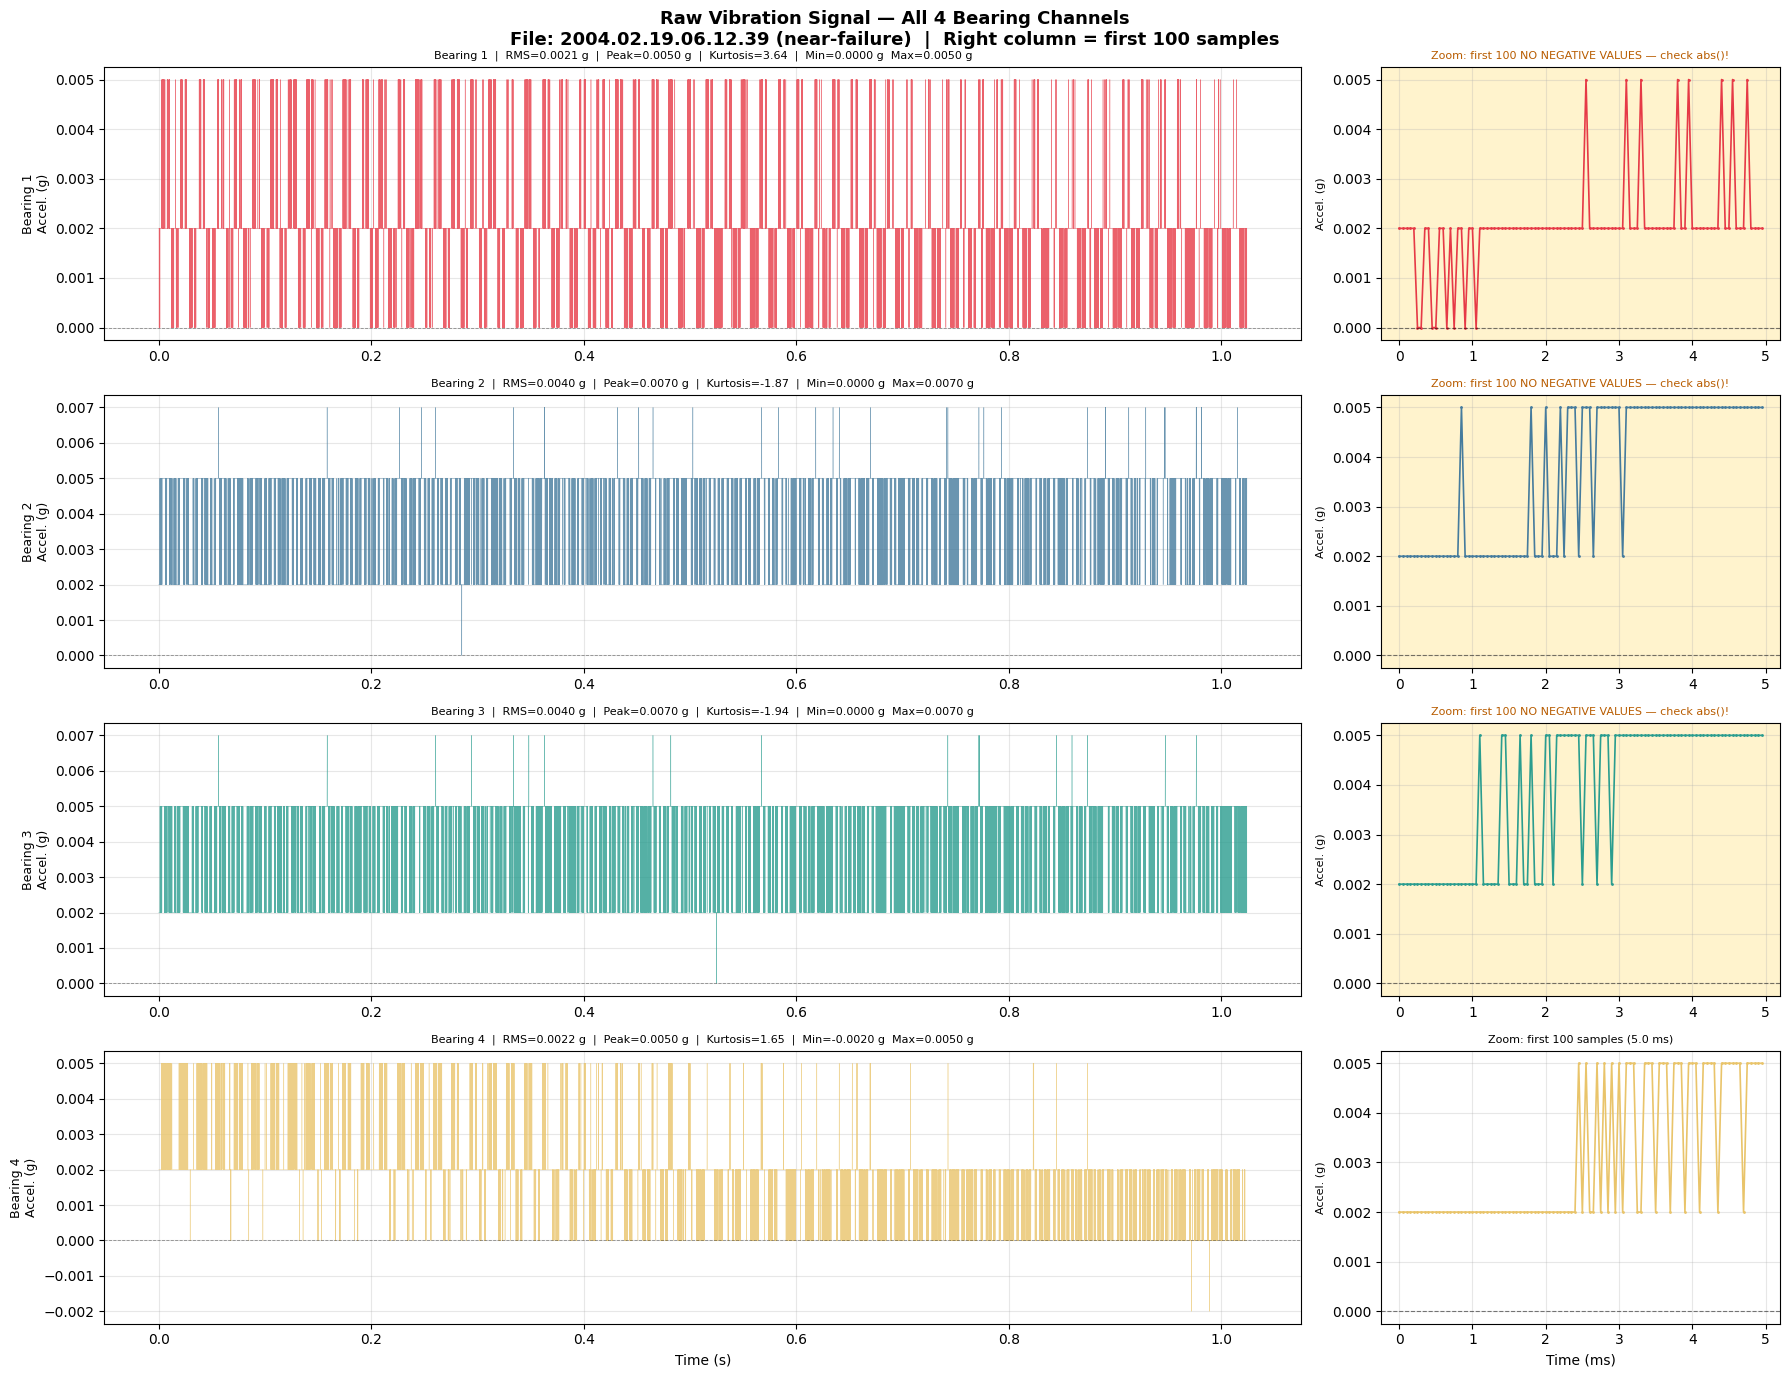

Raw signal plotted from: 2004.02.19.06.12.39
Signal shape: (20480, 4)  →  20480 samples × 4 channels
Duration: 1.0240 s  |  Sampling rate: 20000 Hz



,Channel,Min,Max,Has negatives,Note
0,Bearing 1,0.000,0.005,False,possible abs() issue
1,Bearing 2,0.000,0.007,False,possible abs() issue
2,Bearing 3,0.000,0.007,False,possible abs() issue
3,Bearing 4,-0.002,0.005,True,


In [8]:
# Run: plot signal, then print diagnostics using the same data (no re-read)
raw_data, raw_file = plot_raw_signal_all_bearings(data_dir, file_index=-2)
print_signal_diagnostics(raw_data, raw_file)

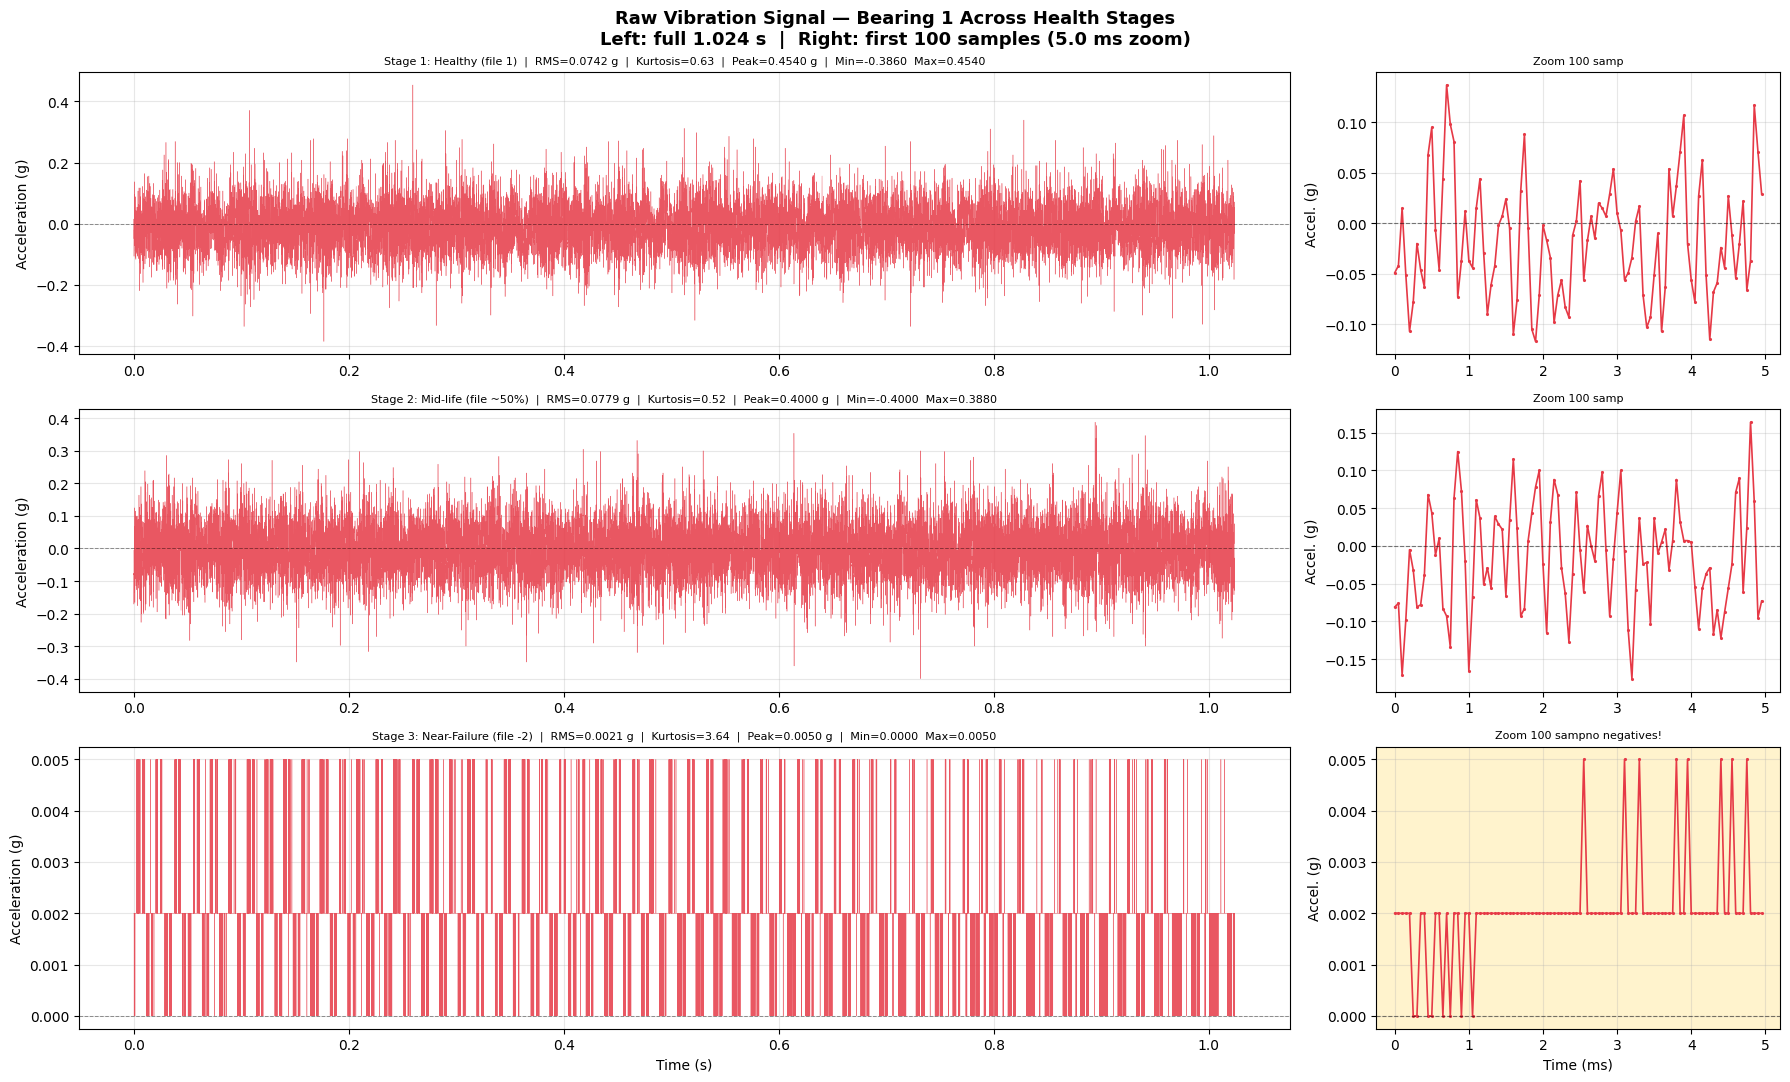

In [17]:
# Step 1.0b — Raw signal evolution: healthy -> mid-life -> near-failure.
# Shows Bearing 1 (the one that fails) at 3 stages to see how the waveform changes.

def plot_raw_signal_3_stages_bearing1(data_dir, zoom_samples=100):
    # Left column: full 1.024s waveform per stage. Right column: first
    # zoom_samples (verify sign/clipping). Zero-crossing line on every panel.
    all_files = sorted(glob.glob(os.path.join(data_dir, "*.*.*.*.*.*")))
    stages = {
        'Stage 1: Healthy (file 1)':      all_files[0],
        'Stage 2: Mid-life (file ~50%)':   all_files[len(all_files)//2],
        'Stage 3: Near-Failure (file -2)': all_files[-2],
    }
    t      = np.arange(N_POINTS) / FS
    t_zoom = np.arange(zoom_samples) / FS * 1000  # ms

    fig, axes = plt.subplots(3, 2, figsize=(18, 11),
                             gridspec_kw={'width_ratios': [3, 1]})
    fig.suptitle(
        'Raw Vibration Signal — Bearing 1 Across Health Stages\n'
        f'Left: full 1.024 s  |  Right: first {zoom_samples} samples ({zoom_samples/FS*1000:.1f} ms zoom)',
        fontsize=13, fontweight='bold'
    )

    for row, (label, fpath) in enumerate(stages.items()):
        sig      = pd.read_csv(fpath, sep=r'\s+', header=None).values[:, 0]
        sig_zoom = sig[:zoom_samples]
        rms_val  = np.sqrt(np.mean(sig**2))
        kurt_val = kurtosis(sig)

        title_str = (f"{label}  |  RMS={rms_val:.4f} g  |  Kurtosis={kurt_val:.2f}  "
                     f"|  Peak={np.max(np.abs(sig)):.4f} g  "
                     f"|  Min={sig.min():.4f}  Max={sig.max():.4f}")

        # Full signal:
        axes[row, 0].plot(t, sig, color=COLORS[0], lw=0.3, alpha=0.85)
        axes[row, 0].axhline(0, color='k', lw=0.7, ls='--', alpha=0.4)
        axes[row, 0].set_title(title_str, fontsize=8)
        axes[row, 0].set_ylabel('Acceleration (g)')
        axes[row, 0].grid(True, alpha=0.3)

        # annotate impact spikes on near-failure full plot
        if 'Near-Failure' in label:
            threshold = 3 * rms_val
            impact_idx = np.where(np.abs(sig) > threshold)[0]
            if len(impact_idx):
                axes[row, 0].scatter(t[impact_idx], sig[impact_idx],
                                     color='red', s=4, zorder=5, label=f'|x|>3σ ({len(impact_idx)} pts)')
                axes[row, 0].legend(fontsize=8)

        # Zoom 
        axes[row, 1].plot(t_zoom, sig_zoom, color=COLORS[0], lw=1.2,
                          marker='.', markersize=2.5)
        axes[row, 1].axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
        axes[row, 1].set_ylabel('Accel. (g)')
        axes[row, 1].grid(True, alpha=0.3)

        # warning if no negative values
        zoom_title = f'Zoom {zoom_samples} samp'
        if sig.min() >= 0:
            axes[row, 1].set_facecolor('#fff3cd')
            zoom_title += 'no negatives!'
        axes[row, 1].set_title(zoom_title, fontsize=8)

    axes[-1, 0].set_xlabel('Time (s)')
    axes[-1, 1].set_xlabel('Time (ms)')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, '0b_raw_signal_B1_stages.png'),
                dpi=300, bbox_inches='tight')
    plt.show()


plot_raw_signal_3_stages_bearing1(data_dir)

### Step 1.1 — Data Integrity & Basic Statistics

In [18]:
# use df_raw directly
df_features = df_raw.copy()

print(f"Dataset shape: {df_features.shape}")
print(f"Time range   : {df_features['timestamp'].min()}  →  {df_features['timestamp'].max()}")
print(f"Duration     : {df_features['timestamp'].max() - df_features['timestamp'].min()}")

print("\nMissing values (top columns):")
print(df_features.isnull().sum().sort_values(ascending=False).head(10))

print("\nSummary statistics:")
display(df_features.describe().T.round(4))


Dataset shape: (984, 58)
Time range   : 2004-02-12 10:32:39  →  2004-02-19 06:22:39
Duration     : 6 days 19:50:00

Missing values (top columns):
timestamp           0
env_kurtosis_2      0
peak_2              0
kurtosis_2          0
skew_2              0
crest_factor_2      0
std_2               0
shape_factor_2      0
impulse_factor_2    0
bpfo_amp_2          0
dtype: int64

Summary statistics:


,count,mean,min,25%,50%,75%,max,std
timestamp,984,2004-02-15 20:27:39.000000384,2004-02-12 10:32:39,2004-02-14 03:30:09,2004-02-15 20:27:39,2004-02-17 13:25:09,2004-02-19 06:22:39,NaN
rms_0,984.0,0.106111,0.001533,0.077137,0.078778,0.108819,0.725001,0.058224
peak_0,984.0,0.555001,0.005,0.393,0.442,0.576,5.0,0.388084
kurtosis_0,984.0,0.827138,-1.609774,0.393747,0.484787,0.878688,14.110009,0.965787
skew_0,984.0,-0.033123,-0.766067,-0.047506,-0.009859,0.013705,0.579698,0.089029
crest_factor_0,984.0,5.17387,2.377543,4.816583,5.097702,5.440354,9.33327,0.576209
std_0,984.0,0.106087,0.000987,0.077108,0.078745,0.108787,0.724996,0.058231
shape_factor_0,984.0,1.296404,1.132578,1.268805,1.273184,1.304257,1.612963,0.047856
impulse_factor_0,984.0,6.711379,2.692753,6.187413,6.59846,7.108115,13.957178,0.838333
bpfo_amp_0,984.0,0.00022,0.000001,0.00012,0.000193,0.000285,0.001926,0.000158


### Step 1.2 — Time-Domain & Frequency-Domain Visualization

Running Step 1.2 plots on raw (unsmoothed) data...


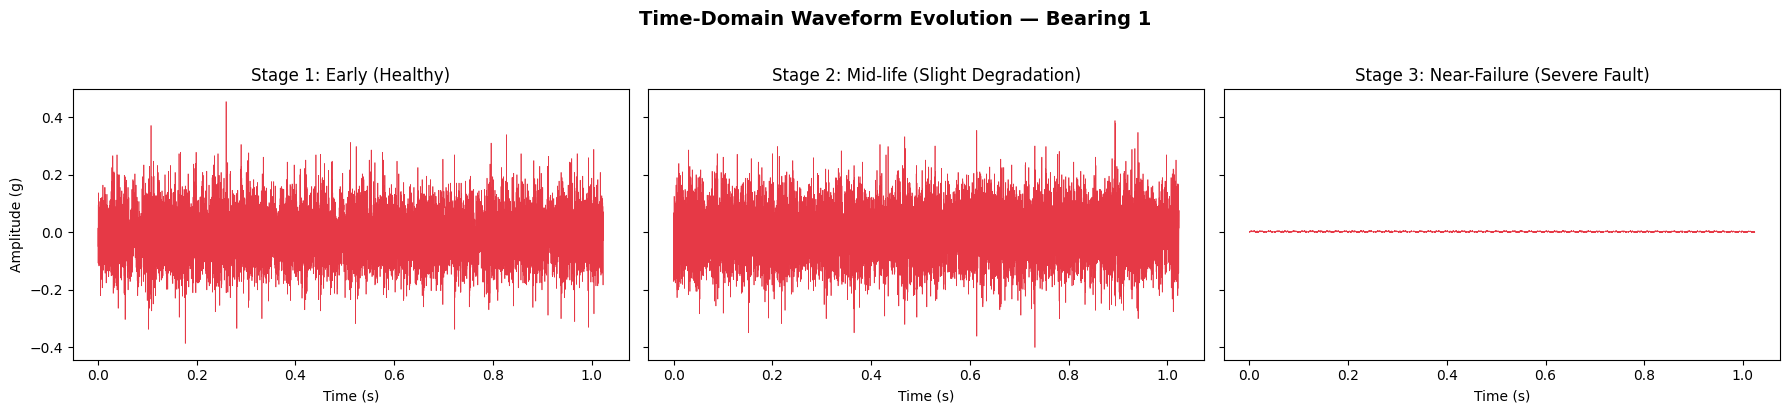

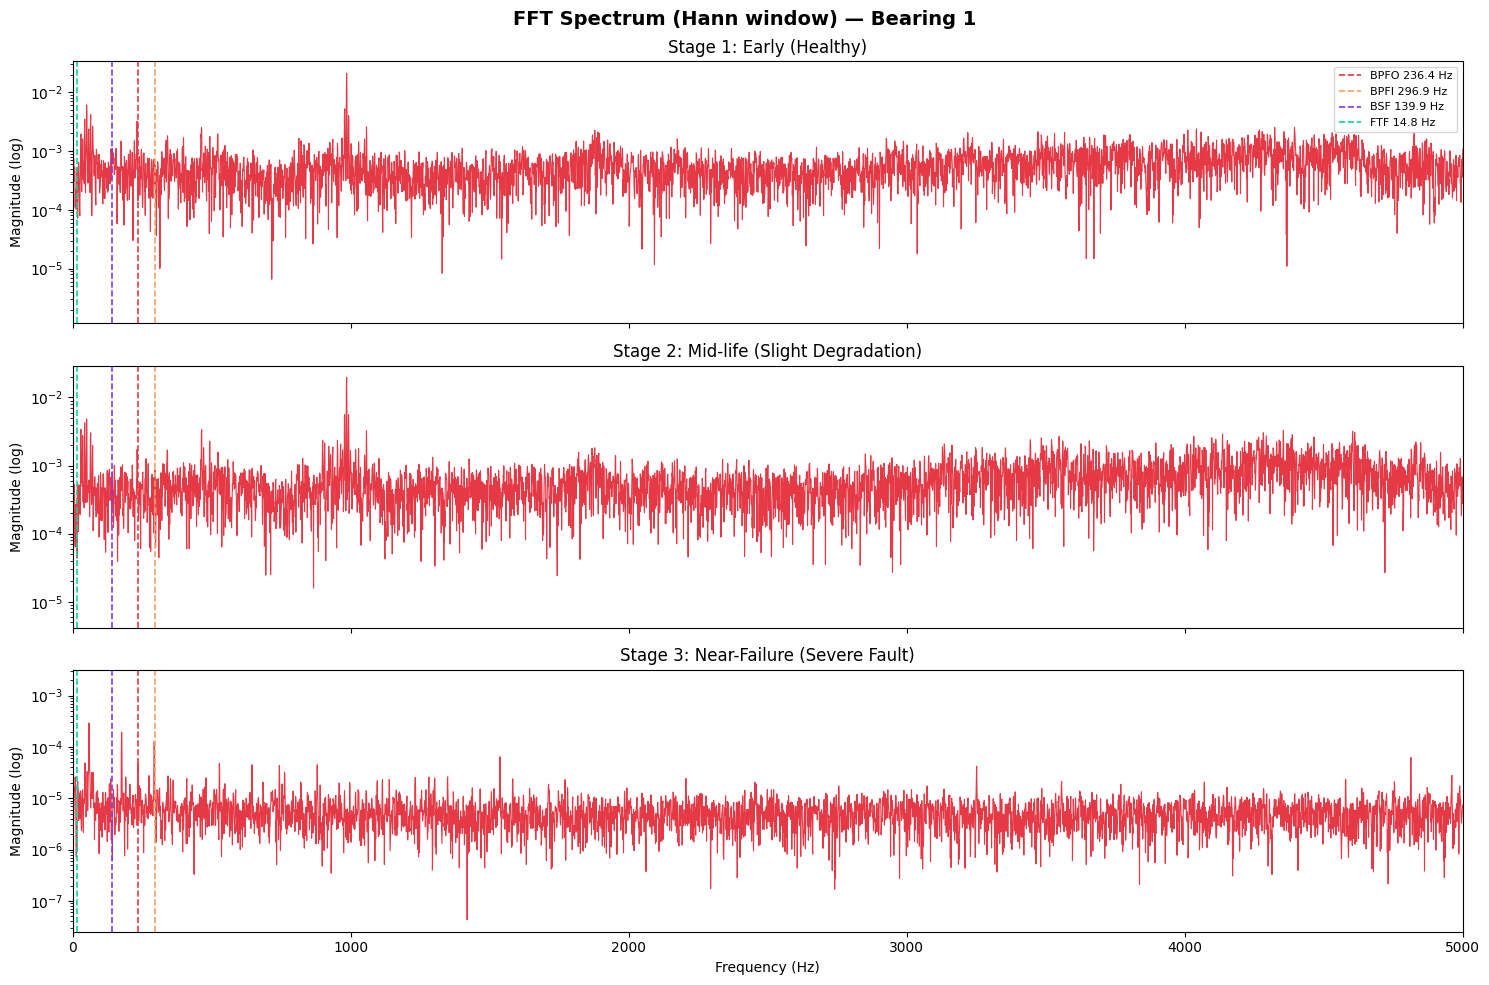

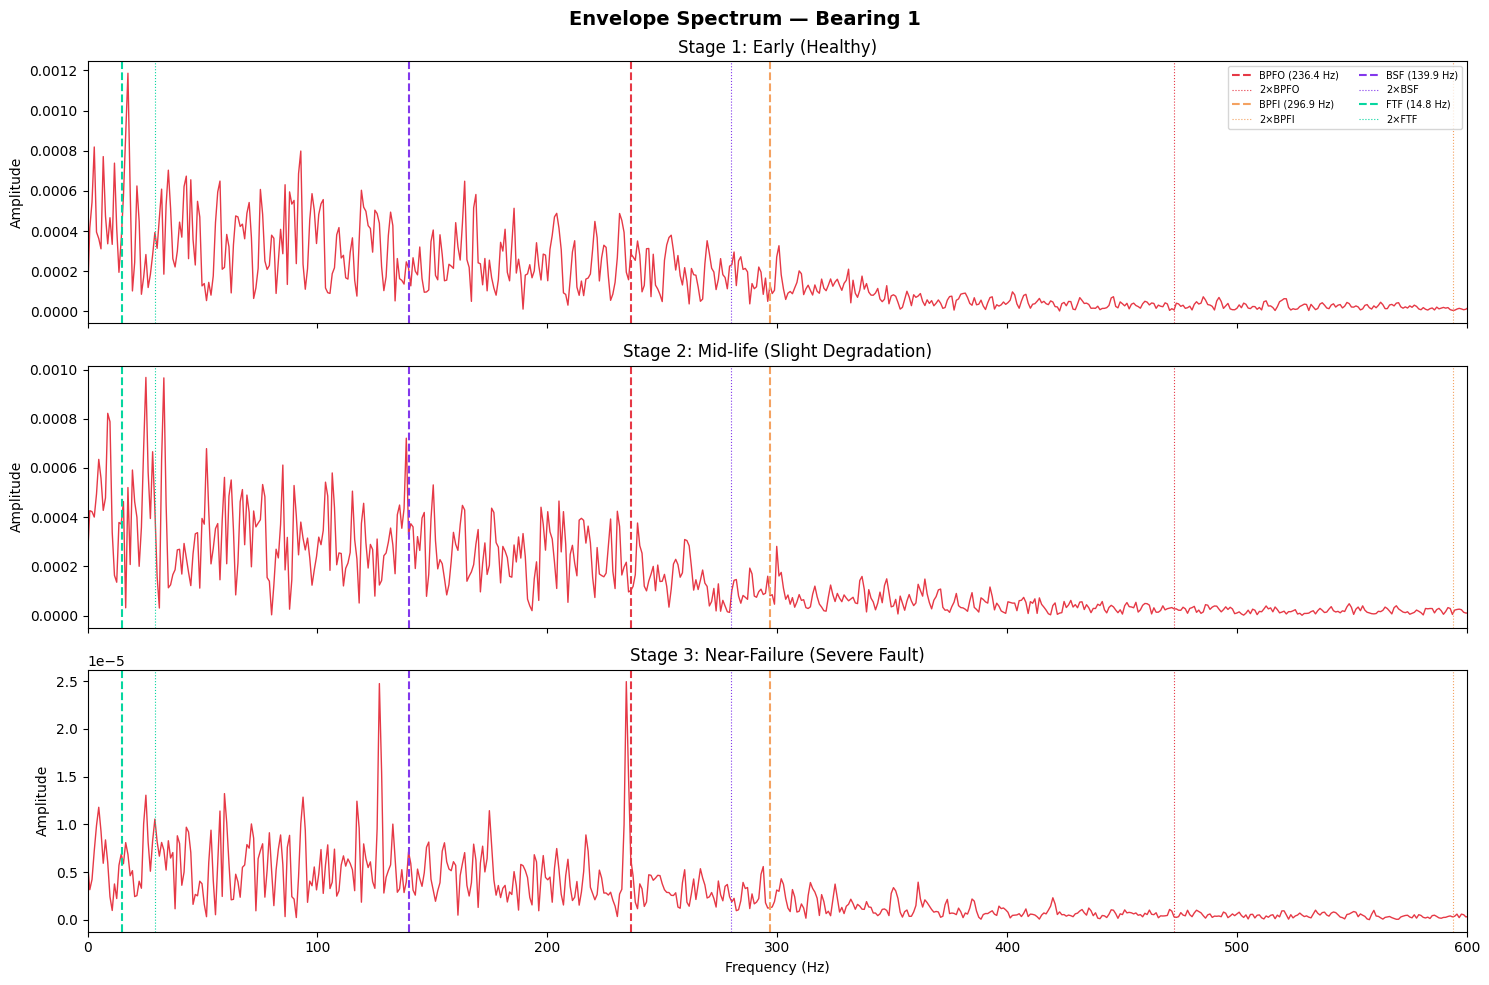

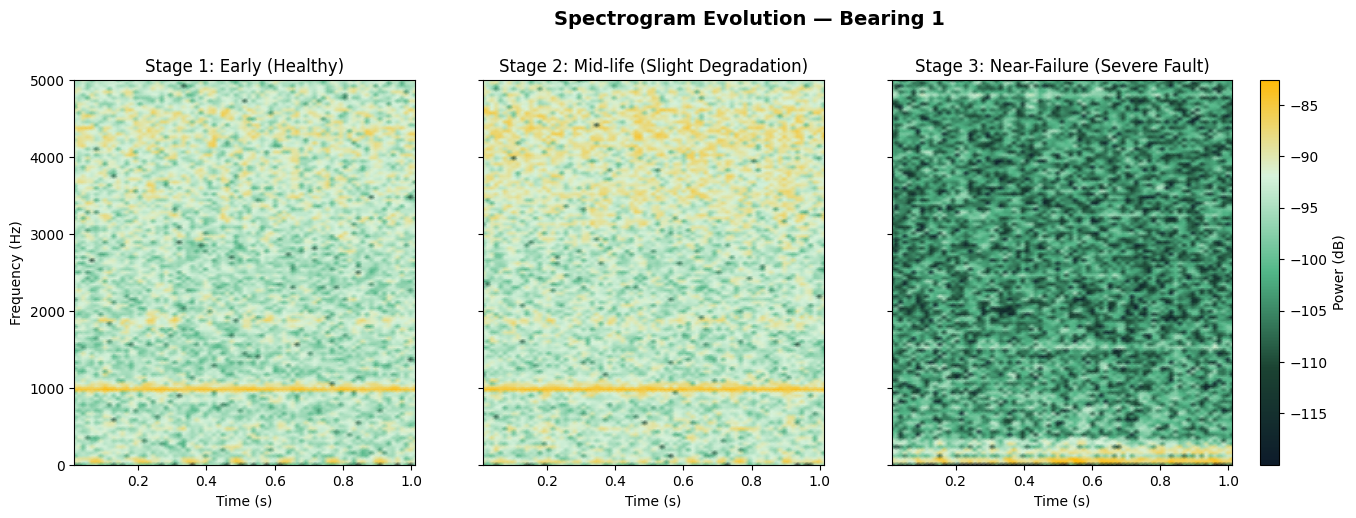

In [19]:
def get_representative_files(data_dir):
    # Selects 3 files: early healthy, mid-life, near-failure.
    all_files = sorted(glob.glob(os.path.join(data_dir, "*.*.*.*.*.*")))
    if len(all_files) < 3:
        return []
    rep = [
        {'label': 'Stage 1: Early (Healthy)',             'path': all_files[0]},
        {'label': 'Stage 2: Mid-life (Slight Degradation)','path': all_files[len(all_files)//2]},
        {'label': 'Stage 3: Near-Failure (Severe Fault)',  'path': all_files[-2]},
    ]
    for r in rep:
        r['data'] = pd.read_csv(r['path'], sep=r'\s+', header=None).values
    return rep

representative_files = get_representative_files(data_dir)


# Plot 1: Raw waveforms 
def plot_waveforms_stages(rep_files, bearing_idx=0):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    fig.suptitle(f"Time-Domain Waveform Evolution — {BEARINGS[bearing_idx]}",
                 fontsize=14, fontweight='bold', y=1.02)
    t = np.arange(N_POINTS) / FS
    for i, rf in enumerate(rep_files):
        sig = rf['data'][:, bearing_idx]
        axes[i].plot(t, sig, color=COLORS[bearing_idx], lw=0.5)
        axes[i].set_title(rf['label'])
        axes[i].set_xlabel('Time (s)')
        if i == 0:
            axes[i].set_ylabel('Amplitude (g)')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'1_waveforms_B{bearing_idx+1}.png'), dpi=300, bbox_inches='tight')
    plt.show()


#  Plot 2: FFT spectrum (with Hann window) 
def plot_fft_stages(rep_files, bearing_idx=0):
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig.suptitle(f"FFT Spectrum (Hann window) — {BEARINGS[bearing_idx]}",
                 fontsize=14, fontweight='bold')
    for i, rf in enumerate(rep_files):
        sig = rf['data'][:, bearing_idx]
        xf, mag = get_fft_spectrum(sig)
        axes[i].semilogy(xf, mag + 1e-10, color=COLORS[bearing_idx], lw=0.8)
        axes[i].set_title(rf['label'])
        axes[i].set_ylabel('Magnitude (log)')
        axes[i].set_xlim(0, 5000)
        # annotate all 4 fault frequencies
        for (name, freq), fc in zip(FAULT_FREQ_LABELS.items(), FAULT_COLORS):
            axes[i].axvline(freq, color=fc, ls='--', lw=1.2,
                            label=f'{name} {freq:.1f} Hz')
        if i == 0:
            axes[i].legend(fontsize=8, loc='upper right')
    axes[-1].set_xlabel('Frequency (Hz)')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'2_fft_B{bearing_idx+1}.png'), dpi=300, bbox_inches='tight')
    plt.show()


# Plot 3: Envelope spectrum 
def plot_envelope_spectrum_stages(rep_files, bearing_idx=0):
    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig.suptitle(f"Envelope Spectrum — {BEARINGS[bearing_idx]}",
                 fontsize=14, fontweight='bold')
    for i, rf in enumerate(rep_files):
        sig = rf['data'][:, bearing_idx]
        xf, amp = get_envelope_spectrum(sig)
        axes[i].plot(xf, amp, color=COLORS[bearing_idx], lw=1)
        axes[i].set_title(rf['label'])
        axes[i].set_ylabel('Amplitude')
        axes[i].set_xlim(0, 600)
        # all 4 fault freqs + 2nd harmonics 
        for (name, freq), fc in zip(FAULT_FREQ_LABELS.items(), FAULT_COLORS):
            axes[i].axvline(freq,   color=fc, ls='--', lw=1.5,
                            label=f'{name} ({freq:.1f} Hz)')
            axes[i].axvline(freq*2, color=fc, ls=':',  lw=0.8,
                            label=f'2×{name}')
        if i == 0:
            axes[i].legend(fontsize=7, loc='upper right', ncol=2)
    axes[-1].set_xlabel('Frequency (Hz)')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'3_envelope_B{bearing_idx+1}.png'), dpi=300, bbox_inches='tight')
    plt.show()


# Plot 4: Spectrogram 
def plot_spectrogram_stages(rep_files, bearing_idx=0):
    cmap = LinearSegmentedColormap.from_list(
        'custom', ['#0d1b2a','#1b4332','#52b788','#d8f3dc','#ffba08'])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(f"Spectrogram Evolution — {BEARINGS[bearing_idx]}",
                 fontsize=14, fontweight='bold', y=1.02)
    for i, rf in enumerate(rep_files):
        sig = rf['data'][:, bearing_idx]
        f, t_seg, Sxx = sp_signal.spectrogram(sig, fs=FS, nperseg=512, noverlap=256)
        Sxx_db = 10 * np.log10(Sxx + 1e-12)
        im = axes[i].pcolormesh(t_seg, f, Sxx_db, shading='gouraud', cmap=cmap)
        axes[i].set_ylim(0, 5000)
        axes[i].set_xlabel('Time (s)')
        axes[i].set_title(rf['label'])
        if i == 0:
            axes[i].set_ylabel('Frequency (Hz)')
    fig.colorbar(im, ax=axes.ravel().tolist(), label='Power (dB)', pad=0.02)
    plt.savefig(os.path.join(plot_dir, f'4_spectrogram_B{bearing_idx+1}.png'), dpi=300, bbox_inches='tight')
    plt.show()


print("Running Step 1.2 plots on raw (unsmoothed) data...")
plot_waveforms_stages(representative_files, bearing_idx=0)
plot_fft_stages(representative_files, bearing_idx=0)
plot_envelope_spectrum_stages(representative_files, bearing_idx=0)
plot_spectrogram_stages(representative_files, bearing_idx=0)

### Step 1.3 — Statistical Distribution Analysis

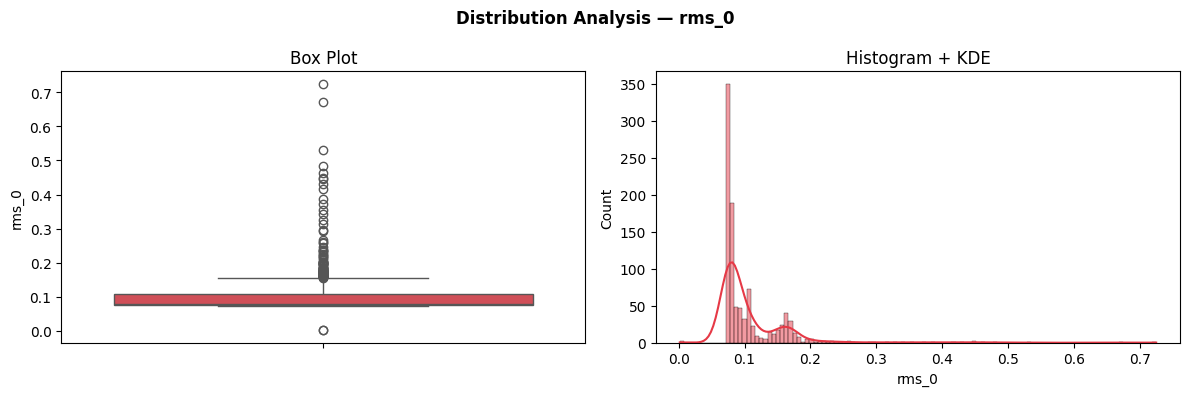

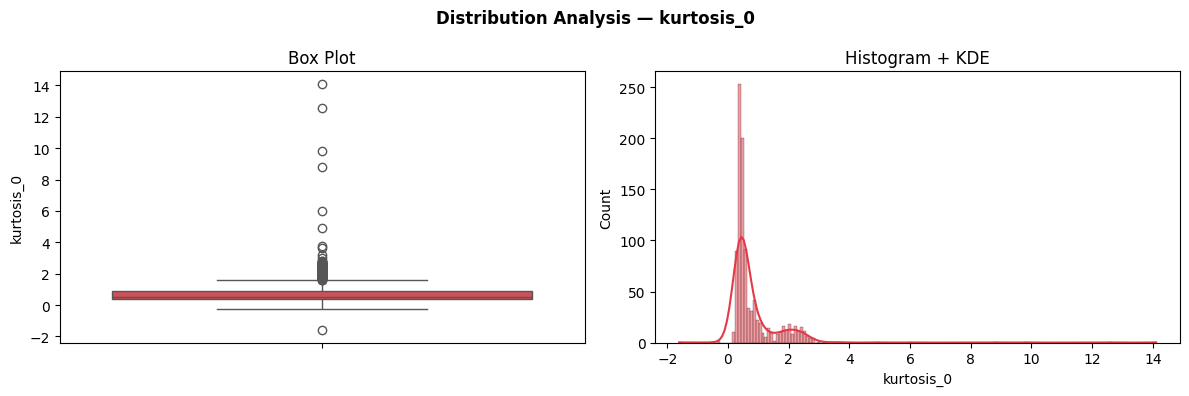

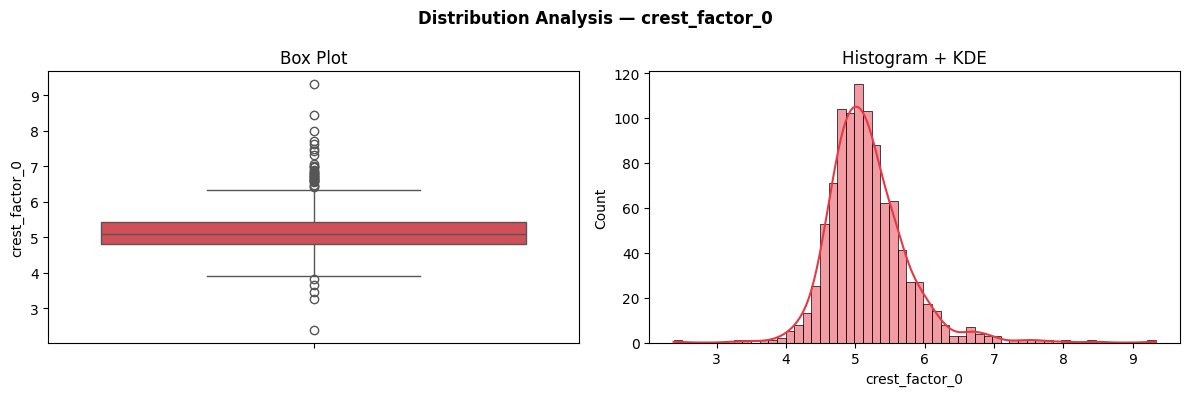

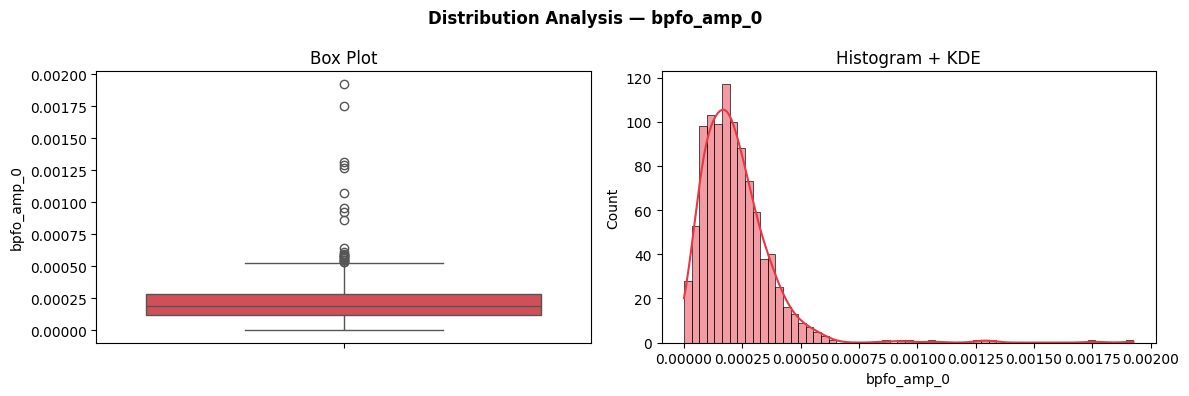

In [12]:
#corrected column names (suffix _0 = Bearing 1)
distribution_features = ['rms_0', 'kurtosis_0', 'crest_factor_0', 'bpfo_amp_0']

for feature in distribution_features:
    if feature not in df_features.columns:
        print(f"  [skip] column '{feature}' not found")
        continue
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Distribution Analysis — {feature}', fontweight='bold')

    sns.boxplot(y=df_features[feature], ax=axes[0], color=COLORS[0])
    axes[0].set_title('Box Plot')

    sns.histplot(df_features[feature], kde=True, ax=axes[1], color=COLORS[0])
    axes[1].set_title('Histogram + KDE')

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'5_dist_{feature}.png'), dpi=150, bbox_inches='tight')
    plt.show()


### Step 1.3b — Distribution: Healthy vs Degraded Conditions

Step 1.3 shows the combined distribution over all 984 snapshots (healthy and
degraded together). Here the data is split into a healthy baseline (first 200
files) and degraded (remaining files) to see how each feature's distribution
shifts — this is the motivation for the features chosen later.

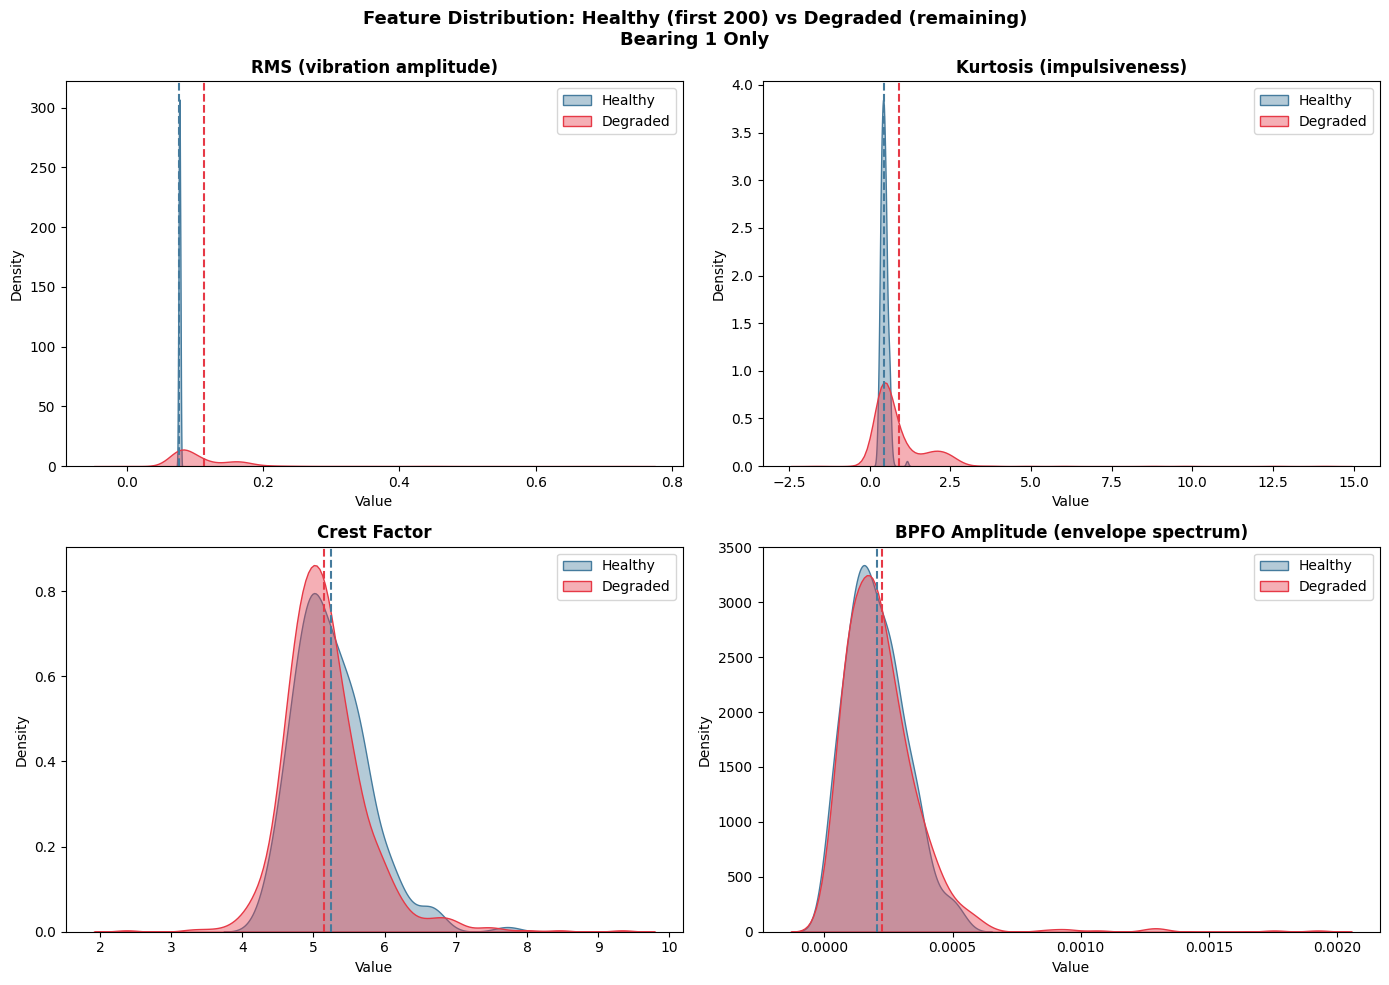


Mean values — Healthy vs Degraded:
                Healthy  Degraded
rms_0            0.0773    0.1135
kurtosis_0       0.4471    0.9241
crest_factor_0   5.2509    5.1542
bpfo_amp_0       0.0002    0.0002


In [13]:
# Step 1.3b — Overlay distributions: Healthy vs Degraded

# Simple split: first HEALTHY_N=200 files = healthy baseline, rest = degraded
# (requires timestamp-sorted data)
assert df_features['timestamp'].is_monotonic_increasing, \
    "df_features must be sorted by timestamp before healthy/degraded split"
df_healthy  = df_features.iloc[:HEALTHY_N].copy()
df_degraded = df_features.iloc[HEALTHY_N:].copy()

split_features = ['rms_0', 'kurtosis_0', 'crest_factor_0', 'bpfo_amp_0']
feature_labels = {
    'rms_0':          'RMS (vibration amplitude)',
    'kurtosis_0':     'Kurtosis (impulsiveness)',
    'crest_factor_0': 'Crest Factor',
    'bpfo_amp_0':     'BPFO Amplitude (envelope spectrum)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Feature Distribution: Healthy (first 200) vs Degraded (remaining)\n'
    'Bearing 1 Only',
    fontsize=13, fontweight='bold'
)

for ax, feat in zip(axes.flat, split_features):
    if feat not in df_features.columns:
        ax.set_visible(False)
        continue
    sns.kdeplot(df_healthy[feat].dropna(),  ax=ax, label='Healthy',  color='#457b9d', fill=True, alpha=0.4)
    sns.kdeplot(df_degraded[feat].dropna(), ax=ax, label='Degraded', color='#e63946', fill=True, alpha=0.4)
    ax.set_title(feature_labels.get(feat, feat), fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
    # add mean lines
    ax.axvline(df_healthy[feat].mean(),  color='#457b9d', ls='--', lw=1.5, label='Healthy mean')
    ax.axvline(df_degraded[feat].mean(), color='#e63946', ls='--', lw=1.5, label='Degraded mean')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '5b_dist_healthy_vs_degraded.png'),
            dpi=300, bbox_inches='tight')
plt.show()

print("\nMean values — Healthy vs Degraded:")
print(df_features[split_features].iloc[:HEALTHY_N].mean().rename('Healthy').to_frame().join(
      df_features[split_features].iloc[HEALTHY_N:].mean().rename('Degraded')).round(4))

### Step 1.4 — Lag Analysis (Autocorrelation)

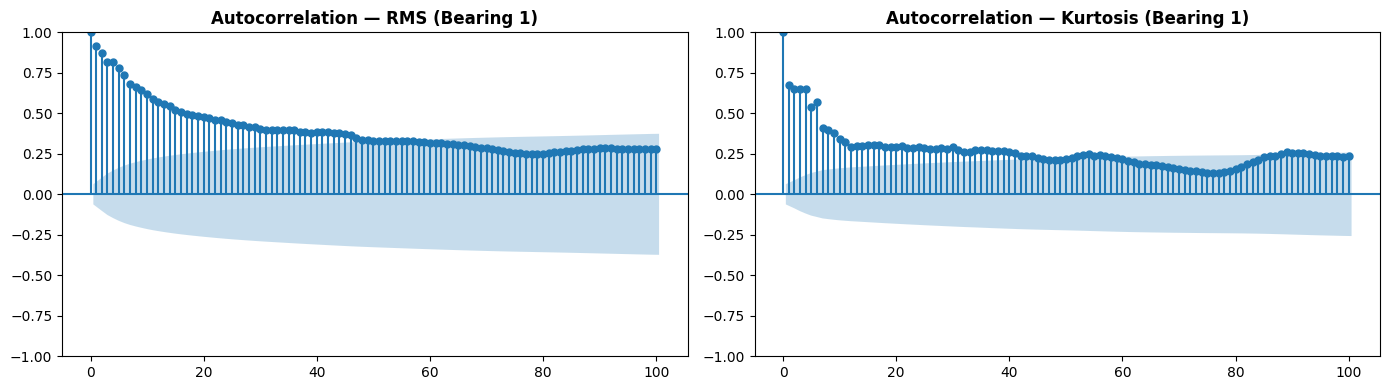

Strong autocorrelation (slow decay) justifies sliding-window approach in RUL modeling.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Guard: lags must be < len(series)/2 (statsmodels requirement)
max_lags = min(100, len(df_features['rms_0'].dropna()) // 2 - 1)

# RMS autocorrelation (Bearing 1)
plot_acf(df_features['rms_0'].dropna(), lags=max_lags, ax=axes[0])
axes[0].set_title('Autocorrelation — RMS (Bearing 1)', fontweight='bold')

# Kurtosis autocorrelation
plot_acf(df_features['kurtosis_0'].dropna(), lags=max_lags, ax=axes[1])
axes[1].set_title('Autocorrelation — Kurtosis (Bearing 1)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(plot_dir, '6_autocorrelation.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Strong autocorrelation (slow decay) justifies sliding-window approach in RUL modeling.")


### Step 1.4b — Autocorrelation of the Raw Signal

Two levels of autocorrelation are analysed:
1. **Within-file ACF** — autocorrelation of the raw vibration samples inside a single
   1.024 s window, showing periodic structure at fault frequencies (e.g., BPFO period
   = 1/236.4 ≈ 4.2 ms).
2. **Cross-file ACF** (Step 1.4) — autocorrelation of the RMS time-series across 984
   snapshots, showing long-range degradation memory that justifies a sliding-window
   approach for RUL models.

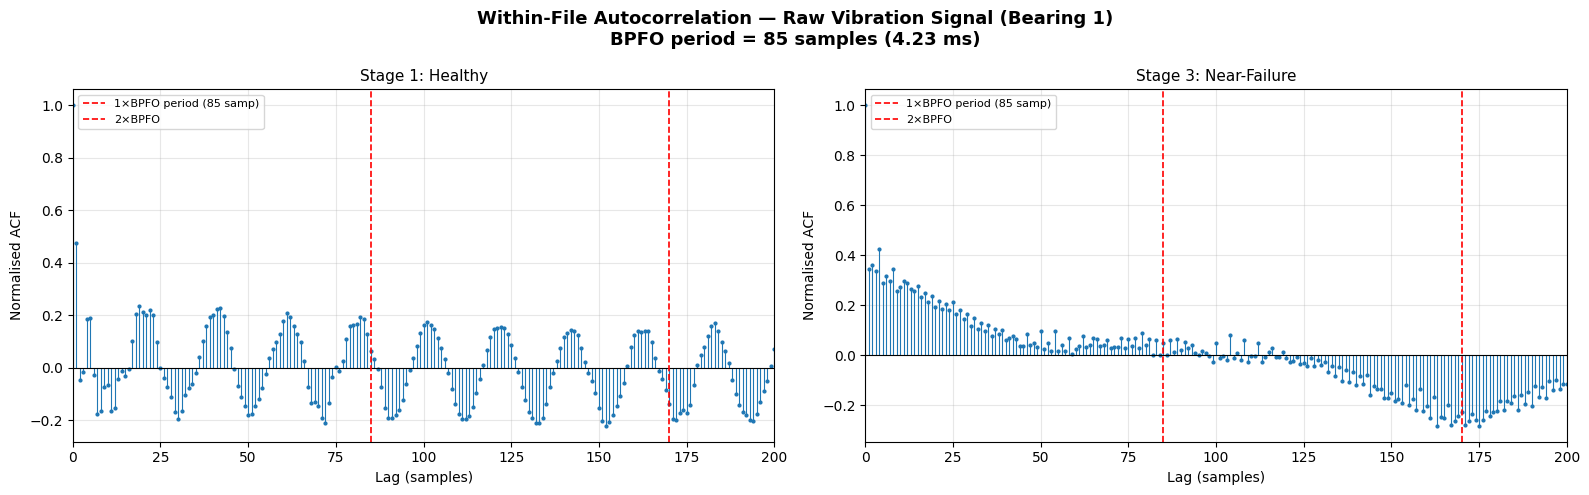

BPFO period = 85 samples = 4.23 ms
Near-failure signal should show peaks at multiples of this period.


In [15]:
# Step 1.4b — Autocorrelation of the raw vibration signal (within-file, not the RMS time-series)

def plot_within_file_acf(data_dir, n_lags=200):
    # Autocorrelation of the raw 20,480-sample signal, healthy vs near-failure
    # (Bearing 1). A real fault should show periodic peaks at multiples of the
    # BPFO period (1/236.4 Hz ≈ 84.6 samples @ 20 kHz).
    all_files = sorted(glob.glob(os.path.join(data_dir, "*.*.*.*.*.*")))
    healthy_sig  = pd.read_csv(all_files[0],   sep=r'\s+', header=None).values[:, 0]
    failure_sig  = pd.read_csv(all_files[-2],  sep=r'\s+', header=None).values[:, 0]

    bpfo_period_samples = int(round(FS / BPFO))  # ≈ 85 samples

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        'Within-File Autocorrelation — Raw Vibration Signal (Bearing 1)\n'
        f'BPFO period = {bpfo_period_samples} samples ({1000/BPFO:.2f} ms)',
        fontsize=13, fontweight='bold'
    )
    for ax, sig, title in zip(
        axes,
        [healthy_sig, failure_sig],
        ['Stage 1: Healthy', 'Stage 3: Near-Failure']
    ):
        # manual ACF (full correlation, not statsmodels — avoids lag limit)
        sig_norm = sig - sig.mean()
        acf_vals = np.correlate(sig_norm, sig_norm, mode='full')
        acf_vals = acf_vals[len(acf_vals)//2:] / acf_vals[len(acf_vals)//2]  # normalise
        lags = np.arange(n_lags + 1)
        # use vlines instead of stem for performance + matplotlib>=3.7 compat
        ax.vlines(lags, 0, acf_vals[:n_lags+1], colors='C0', linewidth=0.8)
        ax.plot(lags, acf_vals[:n_lags+1], 'C0o', markersize=2)
        ax.axhline(0, color='k', linewidth=0.8)
        # mark expected BPFO harmonics (dynamic range based on n_lags)
        max_k = n_lags // bpfo_period_samples
        for k in range(1, max_k + 1):
            xpos = k * bpfo_period_samples
            ax.axvline(xpos, color='red', ls='--', lw=1.2,
                       label=f'{k}×BPFO period ({xpos} samp)' if k == 1 else f'{k}×BPFO')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Lag (samples)')
        ax.set_ylabel('Normalised ACF')
        ax.legend(fontsize=8)
        ax.set_xlim(0, n_lags)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, '6b_acf_raw_signal.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"BPFO period = {bpfo_period_samples} samples = {1000/BPFO:.2f} ms")
    print("Near-failure signal should show peaks at multiples of this period.")


plot_within_file_acf(data_dir, n_lags=200)

### Step 1.5 — Degradation Trend Exploration

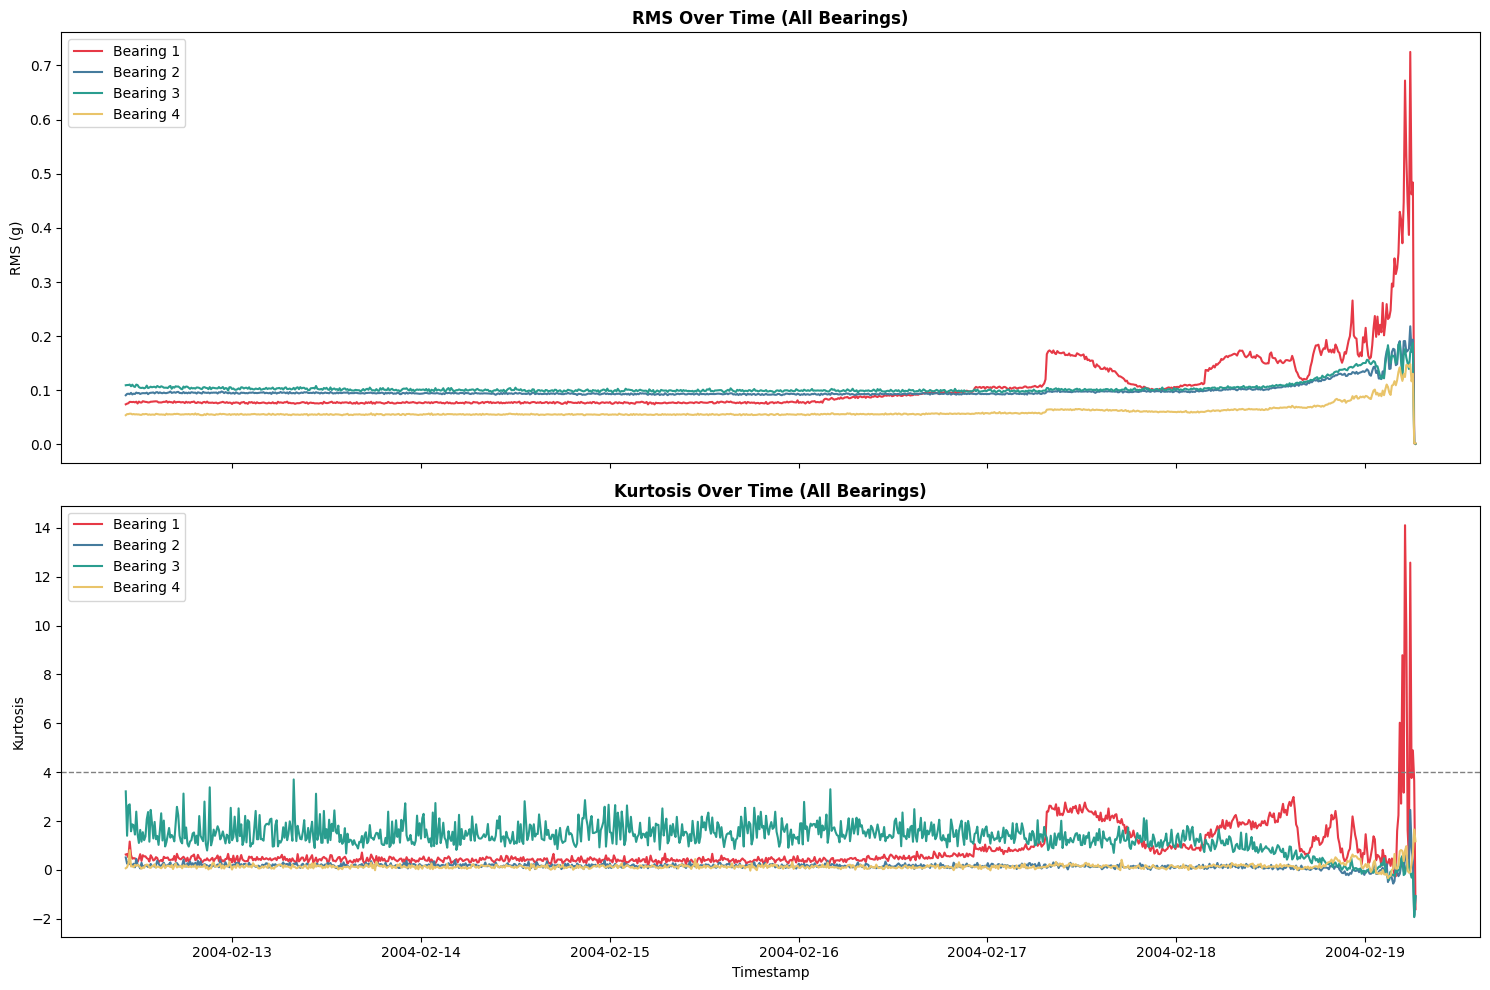

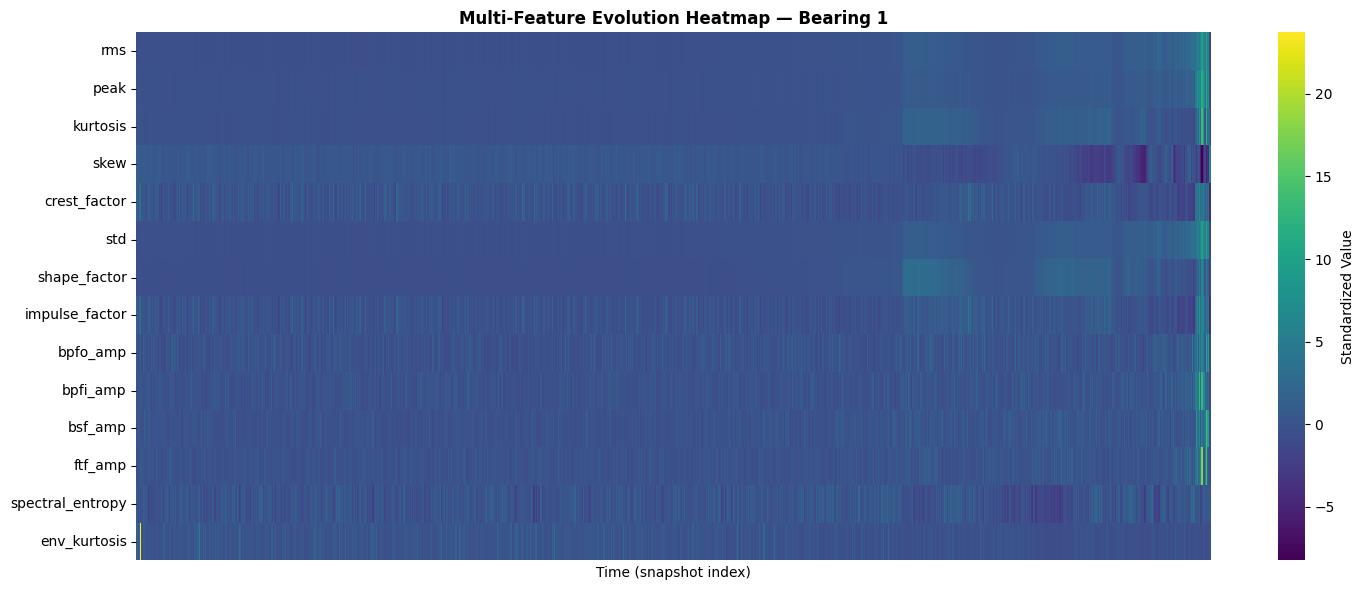

In [20]:
def plot_rms_and_kurtosis_over_time(df):
    # Plots RMS and kurtosis trends over time for all 4 bearings
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    for i in range(4):
        axes[0].plot(df['timestamp'], df[f'rms_{i}'],
                     label=BEARINGS[i], color=COLORS[i], lw=1.5)
        axes[1].plot(df['timestamp'], df[f'kurtosis_{i}'],
                     label=BEARINGS[i], color=COLORS[i], lw=1.5)
    axes[0].set_title('RMS Over Time (All Bearings)', fontweight='bold')
    axes[0].set_ylabel('RMS (g)')
    axes[0].legend(loc='upper left')
    axes[1].set_title('Kurtosis Over Time (All Bearings)', fontweight='bold')
    axes[1].set_ylabel('Kurtosis')
    axes[1].set_xlabel('Timestamp')
    axes[1].legend(loc='upper left')
    axes[1].axhline(4, color='gray', ls='--', lw=1, label='Kurtosis = 4 threshold')  # common fault-onset rule of thumb
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, '7_rms_kurtosis_trend.png'), dpi=300, bbox_inches='tight')
    plt.show()

def plot_multi_feature_heatmap(df, bearing_idx=0):
    # Heatmap of all features for one bearing, standardized so they share a common scale
    cols = [c for c in df.columns
            if c.endswith(f'_{bearing_idx}') and 'health_index' not in c]
    heatmap_data = df[cols].copy()
    sc = StandardScaler()
    heatmap_scaled = sc.fit_transform(heatmap_data)   # z-score each feature so they're comparable side by side
    heatmap_df = pd.DataFrame(
        heatmap_scaled,
        columns=[c.replace(f'_{bearing_idx}', '') for c in cols]
    ).T
    plt.figure(figsize=(15, 6))
    sns.heatmap(heatmap_df, cmap='viridis',
                cbar_kws={'label': 'Standardized Value'}, xticklabels=False)
    plt.title(f'Multi-Feature Evolution Heatmap — {BEARINGS[bearing_idx]}',
              fontweight='bold')
    plt.xlabel('Time (snapshot index)')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f'8_feature_heatmap_B{bearing_idx+1}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

plot_rms_and_kurtosis_over_time(df_features)
plot_multi_feature_heatmap(df_features, bearing_idx=0)

## EDA Conclusions

1. **Which features show clear degradation trends?**
   RMS demonstrates the most stable monotonic trend: flat during healthy state (~first 500 cycles), then continuous increase to failure. Kurtosis reacts earlier but becomes volatile in late stages — excellent for fault detection but less suitable for smooth RUL regression.

2. **Which features exhibit heavy-tailed distributions?**
   Kurtosis spikes to >40 during degradation. Late-stage waveforms show impact spikes reaching ±4g. This proves amplitude distribution is non-Gaussian — mechanical impacts from outer race crack create heavy tails, directly motivating Bayesian priors that account for non-Gaussian noise.

3. **How strong is temporal autocorrelation?**
   Extremely strong (slow ACF decay). Feature at time $t$ is highly dependent on $t-1$, justifying the sliding-window approach in Bayesian LSTM/BNN.

4. **Which features are suitable for Health Index construction?**
   RMS, env_kurtosis, bpfo_amp, crest_factor, std (5 features) — high monotonicity + low mutual redundancy after multicollinearity removal. These 5 features are used consistently in Notebook 2.
